# *Importing libraries*

In [226]:
import numpy as np 
import pandas as pd 

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Encoding
from sklearn.preprocessing import LabelEncoder

# Train test split
from sklearn.model_selection import train_test_split

# Scaling 
from sklearn.preprocessing import StandardScaler

# Nueral Network 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Models
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# *Data Collection*

In [227]:
file_id_1 = "1JM22y7CUA0Dbp2uuVkiUWhIvMctWH2gz"

url = f"https://drive.google.com/uc?export=download&id={file_id_1}"

data_1 = pd.read_csv(url)

In [228]:
data_1.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [229]:
file_id_2 = "1JiWkIQUKoq4tUUH9yoN0LgCDQY4EI5vJ"

url = f"https://drive.google.com/uc?export=download&id={file_id_2}"

data_2 = pd.read_csv(url)

In [230]:
data_2.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City
0,0x2318,COIMBRES13DEL01,NaN,NaN,11.003669,76.976494,11.043669,77.016494,30-03-2022,NaN,15:05:00,conditions NaN,NaN,3,Drinks,electric_scooter,1,No,Metropolitian
1,0x3474,BANGRES15DEL01,28,4.6,12.975377,77.696664,13.085377,77.806664,29-03-2022,20:30:00,20:35:00,conditions Windy,Jam,0,Snack,motorcycle,1,No,Metropolitian
2,0x9420,JAPRES09DEL03,23,4.5,26.911378,75.789034,27.001378,75.879034,10-03-2022,19:35:00,19:45:00,conditions Stormy,Jam,0,Drinks,motorcycle,1,No,Metropolitian
3,0x72ee,JAPRES07DEL03,21,4.8,26.766536,75.837333,26.856536,75.927333,02-04-2022,17:15:00,17:20:00,conditions Fog,Medium,1,Meal,scooter,1,No,Metropolitian
4,0xa759,CHENRES19DEL01,31,4.6,12.986047,80.218114,13.096047,80.328114,27-03-2022,18:25:00,18:40:00,conditions Sunny,Medium,2,Drinks,scooter,1,No,Metropolitian


# *Checking Data_1*

In [231]:
data_1.shape

(45593, 20)

In [232]:
data_1.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)'],
      dtype='object')

In [233]:
data_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

In [234]:
data_1.isnull().sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64

In [235]:
data_1.duplicated().sum()>[0]

array([False])

In [236]:
(data_1 == 'NaN ').sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken(min)                   0
dtype: int64

In [237]:
data_1.describe()

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition
count,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000
mean,17.017729,70.231332,17.465186,70.845702,1.023359
std,8.185109,22.883647,7.335122,21.118812,0.839065
min,-30.905562,-88.366217,0.010000,0.010000,0.000000
25%,12.933284,73.170000,12.988453,73.280000,0.000000
50%,18.546947,75.898497,18.633934,76.002574,1.000000
75%,22.728163,78.044095,22.785049,78.107044,2.000000
max,30.914057,88.433452,31.054057,88.563452,3.000000


# *Checking_Data_2*

In [238]:
data_2.shape

(11399, 19)

In [239]:
data_2.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City'],
      dtype='object')

In [240]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11399 entries, 0 to 11398
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           11399 non-null  object 
 1   Delivery_person_ID           11399 non-null  object 
 2   Delivery_person_Age          11399 non-null  object 
 3   Delivery_person_Ratings      11399 non-null  object 
 4   Restaurant_latitude          11399 non-null  float64
 5   Restaurant_longitude         11399 non-null  float64
 6   Delivery_location_latitude   11399 non-null  float64
 7   Delivery_location_longitude  11399 non-null  float64
 8   Order_Date                   11399 non-null  object 
 9   Time_Orderd                  11399 non-null  object 
 10  Time_Order_picked            11399 non-null  object 
 11  Weatherconditions            11399 non-null  object 
 12  Road_traffic_density         11399 non-null  object 
 13  Vehicle_conditio

In [241]:
data_2.isnull().sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
dtype: int64

In [242]:
data_2.duplicated().sum()>[0]

array([False])

In [243]:
(data_2 == 'NaN ').sum()

ID                               0
Delivery_person_ID               0
Delivery_person_Age            491
Delivery_person_Ratings        507
Restaurant_latitude              0
Restaurant_longitude             0
Delivery_location_latitude       0
Delivery_location_longitude      0
Order_Date                       0
Time_Orderd                    444
Time_Order_picked                0
Weatherconditions                0
Road_traffic_density           154
Vehicle_condition                0
Type_of_order                    0
Type_of_vehicle                  0
multiple_deliveries            238
Festival                        65
City                           324
dtype: int64

In [244]:
data_2.describe()

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition
count,11399.000000,11399.000000,11399.000000,11399.000000,11399.000000
mean,17.099934,70.399259,17.569497,71.102187,1.031406
std,8.193510,22.773144,7.287440,20.693782,0.839599
min,-30.902872,-88.400467,0.010000,0.010000,0.000000
25%,12.933284,73.170937,12.992532,73.771081,0.000000
50%,18.551440,75.897429,18.643481,75.996959,1.000000
75%,22.732225,78.045732,22.791226,78.109004,2.000000
max,30.914057,88.433452,31.054057,88.563452,3.000000


# *Cleaning Data_1*

In [245]:
data_1.drop('ID',axis=1,inplace=True)

In [246]:
data_1.columns

Index(['Delivery_person_ID', 'Delivery_person_Age', 'Delivery_person_Ratings',
       'Restaurant_latitude', 'Restaurant_longitude',
       'Delivery_location_latitude', 'Delivery_location_longitude',
       'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weatherconditions',
       'Road_traffic_density', 'Vehicle_condition', 'Type_of_order',
       'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City',
       'Time_taken(min)'],
      dtype='object')

In [247]:
cols = ['Delivery_person_Age',
        'Delivery_person_Ratings',
        'multiple_deliveries']
data_1[cols] = data_1[cols].replace('NaN ', np.nan)

In [248]:
data_1.isnull().sum()

Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                       0
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density              0
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                          0
City                              0
Time_taken(min)                   0
dtype: int64

# *Cleaning Data_2*

In [249]:
data_2.drop('ID',axis=1,inplace=True)

In [250]:
data_2.columns

Index(['Delivery_person_ID', 'Delivery_person_Age', 'Delivery_person_Ratings',
       'Restaurant_latitude', 'Restaurant_longitude',
       'Delivery_location_latitude', 'Delivery_location_longitude',
       'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weatherconditions',
       'Road_traffic_density', 'Vehicle_condition', 'Type_of_order',
       'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City'],
      dtype='object')

In [251]:
cols = ['Delivery_person_Age',
        'Delivery_person_Ratings',
        'multiple_deliveries']
data_2[cols] = data_2[cols].replace('NaN ', np.nan)

In [252]:
data_2.isnull().sum()

Delivery_person_ID               0
Delivery_person_Age            491
Delivery_person_Ratings        507
Restaurant_latitude              0
Restaurant_longitude             0
Delivery_location_latitude       0
Delivery_location_longitude      0
Order_Date                       0
Time_Orderd                      0
Time_Order_picked                0
Weatherconditions                0
Road_traffic_density             0
Vehicle_condition                0
Type_of_order                    0
Type_of_vehicle                  0
multiple_deliveries            238
Festival                         0
City                             0
dtype: int64

# *Converting Data Types of Data_1*

## column 1

In [253]:
data_1["Delivery_person_Age"].dtype

dtype('O')

In [254]:
data_1['Delivery_person_Age'].unique()

array(['37', '34', '23', '38', '32', '22', '33', '35', '36', '21', '24',
       '29', '25', '31', '27', '26', '20', nan, '28', '39', '30', '15',
       '50'], dtype=object)

In [255]:
data_1['Delivery_person_Age'] = data_1['Delivery_person_Age'].astype(float)

In [256]:
data_1['Delivery_person_Age'].dtype

dtype('float64')

In [257]:
data_1['Delivery_person_Age'].unique()

array([37., 34., 23., 38., 32., 22., 33., 35., 36., 21., 24., 29., 25.,
       31., 27., 26., 20., nan, 28., 39., 30., 15., 50.])

## Column 2 

In [258]:
data_1["Delivery_person_Ratings"].dtype

dtype('O')

In [259]:
data_1['Delivery_person_Ratings'].unique()

array(['4.9', '4.5', '4.4', '4.7', '4.6', '4.8', '4.2', '4.3', '4', '4.1',
       '5', '3.5', nan, '3.8', '3.9', '3.7', '2.6', '2.5', '3.6', '3.1',
       '2.7', '1', '3.2', '3.3', '6', '3.4', '2.8', '2.9', '3'],
      dtype=object)

In [260]:
data_1['Delivery_person_Ratings'] = data_1['Delivery_person_Ratings'].astype(float)

In [261]:
data_1["Delivery_person_Ratings"].dtype

dtype('float64')

In [262]:
data_1['Delivery_person_Ratings'].unique()

array([4.9, 4.5, 4.4, 4.7, 4.6, 4.8, 4.2, 4.3, 4. , 4.1, 5. , 3.5, nan,
       3.8, 3.9, 3.7, 2.6, 2.5, 3.6, 3.1, 2.7, 1. , 3.2, 3.3, 6. , 3.4,
       2.8, 2.9, 3. ])

## Column 3 

In [263]:
data_1["multiple_deliveries"].dtype

dtype('O')

In [264]:
data_1['multiple_deliveries'].unique()

array(['0', '1', '3', nan, '2'], dtype=object)

In [265]:
data_1['multiple_deliveries'] = data_1['multiple_deliveries'].astype(float)

In [266]:
data_1["multiple_deliveries"].dtype

dtype('float64')

In [267]:
data_1['multiple_deliveries'].unique()

array([ 0.,  1.,  3., nan,  2.])

## Column 4

In [268]:
data_1['Time_taken(min)'].dtype

dtype('O')

In [269]:
data_1['Time_taken(min)'].unique()

array(['(min) 24', '(min) 33', '(min) 26', '(min) 21', '(min) 30',
       '(min) 40', '(min) 32', '(min) 34', '(min) 46', '(min) 23',
       '(min) 20', '(min) 41', '(min) 15', '(min) 36', '(min) 39',
       '(min) 18', '(min) 38', '(min) 47', '(min) 12', '(min) 22',
       '(min) 25', '(min) 35', '(min) 10', '(min) 19', '(min) 11',
       '(min) 28', '(min) 52', '(min) 16', '(min) 27', '(min) 49',
       '(min) 17', '(min) 14', '(min) 37', '(min) 44', '(min) 42',
       '(min) 31', '(min) 13', '(min) 29', '(min) 50', '(min) 43',
       '(min) 48', '(min) 54', '(min) 53', '(min) 45', '(min) 51'],
      dtype=object)

In [270]:
data_1['Time_taken(min)'] = data_1['Time_taken(min)'].str.replace('(min) ', '', regex=False)

In [271]:
data_1['Time_taken(min)'] = data_1['Time_taken(min)'].astype(int)

In [272]:
data_1['Time_taken(min)'].dtype

dtype('int64')

In [273]:
data_1['Time_taken(min)'].unique()

array([24, 33, 26, 21, 30, 40, 32, 34, 46, 23, 20, 41, 15, 36, 39, 18, 38,
       47, 12, 22, 25, 35, 10, 19, 11, 28, 52, 16, 27, 49, 17, 14, 37, 44,
       42, 31, 13, 29, 50, 43, 48, 54, 53, 45, 51])

# *Converting Data Types of Data_2*

## Column 1

In [274]:
data_2["Delivery_person_Age"].dtype

dtype('O')

In [275]:
data_2['Delivery_person_Age'].unique()

array([nan, '28', '23', '21', '31', '26', '35', '24', '22', '33', '36',
       '34', '38', '37', '30', '29', '20', '39', '27', '25', '32', '15',
       '50'], dtype=object)

In [276]:
data_2['Delivery_person_Age'] = data_2['Delivery_person_Age'].astype(float)

In [277]:
data_2['Delivery_person_Age'].dtype

dtype('float64')

In [278]:
data_2['Delivery_person_Age'].unique()

array([nan, 28., 23., 21., 31., 26., 35., 24., 22., 33., 36., 34., 38.,
       37., 30., 29., 20., 39., 27., 25., 32., 15., 50.])

## Column 2

In [279]:
data_2["Delivery_person_Ratings"].dtype

dtype('O')

In [280]:
data_2['Delivery_person_Ratings'].unique()

array([nan, '4.6', '4.5', '4.8', '4.7', '4.9', '4.2', '2.7', '5', '4.3',
       '3.8', '4.1', '4.4', '3.9', '4', '3.7', '3.5', '2.8', '3.3', '3.4',
       '1', '3.2', '3.6', '6', '2.6', '2.9', '2.5', '3.1', '3'],
      dtype=object)

In [281]:
data_2['Delivery_person_Ratings'] = data_2['Delivery_person_Ratings'].astype(float)

In [282]:
data_2["Delivery_person_Ratings"].dtype

dtype('float64')

In [283]:
data_2['Delivery_person_Ratings'].unique()

array([nan, 4.6, 4.5, 4.8, 4.7, 4.9, 4.2, 2.7, 5. , 4.3, 3.8, 4.1, 4.4,
       3.9, 4. , 3.7, 3.5, 2.8, 3.3, 3.4, 1. , 3.2, 3.6, 6. , 2.6, 2.9,
       2.5, 3.1, 3. ])

## Column 3

In [284]:
data_2["multiple_deliveries"].dtype

dtype('O')

In [285]:
data_2['multiple_deliveries'].unique()

array(['1', '0', nan, '2', '3'], dtype=object)

In [286]:
data_2['multiple_deliveries'] = data_2['multiple_deliveries'].astype(float)

In [287]:
data_2["multiple_deliveries"].dtype

dtype('float64')

In [288]:
data_2['multiple_deliveries'].unique()

array([ 1.,  0., nan,  2.,  3.])

# *Filling Null Values of Data_1*

In [289]:
data_1.isnull().sum()

Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                       0
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density              0
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                          0
City                              0
Time_taken(min)                   0
dtype: int64

In [290]:
data_1['Delivery_person_Age'].fillna(data_1["Delivery_person_Age"].median(),inplace = True)
data_1['Delivery_person_Ratings'].fillna(data_1["Delivery_person_Ratings"].median(),inplace = True)
data_1['multiple_deliveries'].fillna(data_1["multiple_deliveries"].mode()[0],inplace = True)

C:\Users\HP\AppData\Local\Temp\ipykernel_16508\3574384819.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_1['Delivery_person_Age'].fillna(data_1["Delivery_person_Age"].median(),inplace = True)
C:\Users\HP\AppData\Local\Temp\ipykernel_16508\3574384819.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting valu

In [291]:
data_1.isnull().sum()

Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64

# *Filling Null Values of Data_2*

In [292]:
data_2.isnull().sum()

Delivery_person_ID               0
Delivery_person_Age            491
Delivery_person_Ratings        507
Restaurant_latitude              0
Restaurant_longitude             0
Delivery_location_latitude       0
Delivery_location_longitude      0
Order_Date                       0
Time_Orderd                      0
Time_Order_picked                0
Weatherconditions                0
Road_traffic_density             0
Vehicle_condition                0
Type_of_order                    0
Type_of_vehicle                  0
multiple_deliveries            238
Festival                         0
City                             0
dtype: int64

In [293]:
data_2['Delivery_person_Age'].fillna(data_2["Delivery_person_Age"].median(),inplace = True)
data_2['Delivery_person_Ratings'].fillna(data_2["Delivery_person_Ratings"].median(),inplace = True)
data_2['multiple_deliveries'].fillna(data_2["multiple_deliveries"].mode()[0],inplace = True)

C:\Users\HP\AppData\Local\Temp\ipykernel_16508\2761392605.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_2['Delivery_person_Age'].fillna(data_2["Delivery_person_Age"].median(),inplace = True)
C:\Users\HP\AppData\Local\Temp\ipykernel_16508\2761392605.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting valu

In [294]:
data_2.isnull().sum()

Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
dtype: int64

# *Again Checkhing Data Info of Both Datasets*

In [295]:
data_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Delivery_person_ID           45593 non-null  object 
 1   Delivery_person_Age          45593 non-null  float64
 2   Delivery_person_Ratings      45593 non-null  float64
 3   Restaurant_latitude          45593 non-null  float64
 4   Restaurant_longitude         45593 non-null  float64
 5   Delivery_location_latitude   45593 non-null  float64
 6   Delivery_location_longitude  45593 non-null  float64
 7   Order_Date                   45593 non-null  object 
 8   Time_Orderd                  45593 non-null  object 
 9   Time_Order_picked            45593 non-null  object 
 10  Weatherconditions            45593 non-null  object 
 11  Road_traffic_density         45593 non-null  object 
 12  Vehicle_condition            45593 non-null  int64  
 13  Type_of_order   

In [296]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11399 entries, 0 to 11398
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Delivery_person_ID           11399 non-null  object 
 1   Delivery_person_Age          11399 non-null  float64
 2   Delivery_person_Ratings      11399 non-null  float64
 3   Restaurant_latitude          11399 non-null  float64
 4   Restaurant_longitude         11399 non-null  float64
 5   Delivery_location_latitude   11399 non-null  float64
 6   Delivery_location_longitude  11399 non-null  float64
 7   Order_Date                   11399 non-null  object 
 8   Time_Orderd                  11399 non-null  object 
 9   Time_Order_picked            11399 non-null  object 
 10  Weatherconditions            11399 non-null  object 
 11  Road_traffic_density         11399 non-null  object 
 12  Vehicle_condition            11399 non-null  int64  
 13  Type_of_order   

# *Converting Date And Time Column of Data_1*

In [297]:
data_1.select_dtypes(include='object').columns

Index(['Delivery_person_ID', 'Order_Date', 'Time_Orderd', 'Time_Order_picked',
       'Weatherconditions', 'Road_traffic_density', 'Type_of_order',
       'Type_of_vehicle', 'Festival', 'City'],
      dtype='object')

## Date Column

In [298]:
data_1['Order_Date'].head()

0    19-03-2022
1    25-03-2022
2    19-03-2022
3    05-04-2022
4    26-03-2022
Name: Order_Date, dtype: object

In [299]:
data_1['Order_Date'] = pd.to_datetime(data_1['Order_Date'])

C:\Users\HP\AppData\Local\Temp\ipykernel_16508\3835211906.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data_1['Order_Date'] = pd.to_datetime(data_1['Order_Date'])


In [300]:
data_1['Order_Date'].head()

0   2022-03-19
1   2022-03-25
2   2022-03-19
3   2022-04-05
4   2022-03-26
Name: Order_Date, dtype: datetime64[ns]

## Time Column

In [301]:
data_1['Time_Orderd'].head()

0    11:30:00
1    19:45:00
2    08:30:00
3    18:00:00
4    13:30:00
Name: Time_Orderd, dtype: object

In [302]:
data_1['Time_Order_picked'].head()

0    11:45:00
1    19:50:00
2    08:45:00
3    18:10:00
4    13:45:00
Name: Time_Order_picked, dtype: object

In [303]:
data_1['Time_Orderd'] = data_1['Time_Orderd'].replace('NaN ', np.nan)

In [304]:
data_1['Time_Orderd'] = pd.to_datetime(data_1['Time_Orderd'])
data_1['Time_Order_picked'] = pd.to_datetime(data_1['Time_Order_picked'])

C:\Users\HP\AppData\Local\Temp\ipykernel_16508\3796903424.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data_1['Time_Orderd'] = pd.to_datetime(data_1['Time_Orderd'])
C:\Users\HP\AppData\Local\Temp\ipykernel_16508\3796903424.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data_1['Time_Order_picked'] = pd.to_datetime(data_1['Time_Order_picked'])


In [305]:
data_1['Time_Orderd'].head()

0   2026-05-23 11:30:00
1   2026-05-23 19:45:00
2   2026-05-23 08:30:00
3   2026-05-23 18:00:00
4   2026-05-23 13:30:00
Name: Time_Orderd, dtype: datetime64[ns]

In [306]:
data_1['Time_Order_picked'].head()

0   2026-05-23 11:45:00
1   2026-05-23 19:50:00
2   2026-05-23 08:45:00
3   2026-05-23 18:10:00
4   2026-05-23 13:45:00
Name: Time_Order_picked, dtype: datetime64[ns]

# *Converting Date And Time Column of Data_2*

## Date Column

In [307]:
data_2['Order_Date'].head()

0    30-03-2022
1    29-03-2022
2    10-03-2022
3    02-04-2022
4    27-03-2022
Name: Order_Date, dtype: object

In [308]:
data_2['Order_Date'] = pd.to_datetime(data_2['Order_Date'])

C:\Users\HP\AppData\Local\Temp\ipykernel_16508\2354847407.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data_2['Order_Date'] = pd.to_datetime(data_2['Order_Date'])


## Time Column

In [309]:
data_2['Time_Orderd'].head()

0        NaN 
1    20:30:00
2    19:35:00
3    17:15:00
4    18:25:00
Name: Time_Orderd, dtype: object

In [310]:
data_2['Time_Order_picked'].head()

0    15:05:00
1    20:35:00
2    19:45:00
3    17:20:00
4    18:40:00
Name: Time_Order_picked, dtype: object

In [311]:
data_2['Time_Orderd'] = data_2['Time_Orderd'].replace('NaN ', np.nan)

In [312]:
data_2['Time_Orderd'] = pd.to_datetime(data_2['Time_Orderd'])
data_2['Time_Order_picked'] = pd.to_datetime(data_2['Time_Order_picked'])

C:\Users\HP\AppData\Local\Temp\ipykernel_16508\3843375641.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data_2['Time_Orderd'] = pd.to_datetime(data_2['Time_Orderd'])
C:\Users\HP\AppData\Local\Temp\ipykernel_16508\3843375641.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data_2['Time_Order_picked'] = pd.to_datetime(data_2['Time_Order_picked'])


In [313]:
data_2['Time_Orderd'].head()

0                   NaT
1   2026-05-23 20:30:00
2   2026-05-23 19:35:00
3   2026-05-23 17:15:00
4   2026-05-23 18:25:00
Name: Time_Orderd, dtype: datetime64[ns]

In [314]:
data_2['Time_Order_picked'].head()

0   2026-05-23 15:05:00
1   2026-05-23 20:35:00
2   2026-05-23 19:45:00
3   2026-05-23 17:20:00
4   2026-05-23 18:40:00
Name: Time_Order_picked, dtype: datetime64[ns]

# *Checking and Filling Null values of Date/Time Columns*

In [315]:
data_1[['Order_Date','Time_Orderd','Time_Order_picked']].isnull().sum()

Order_Date              0
Time_Orderd          1731
Time_Order_picked       0
dtype: int64

In [316]:
data_2[['Order_Date','Time_Orderd','Time_Order_picked']].isnull().sum()

Order_Date             0
Time_Orderd          444
Time_Order_picked      0
dtype: int64

In [317]:
data_1['Time_Orderd'].fillna(data_1['Time_Orderd'].mode()[0], inplace=True)
data_2['Time_Orderd'].fillna(data_2['Time_Orderd'].mode()[0], inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_16508\594225965.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_1['Time_Orderd'].fillna(data_1['Time_Orderd'].mode()[0], inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_16508\594225965.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves 

In [318]:
data_1[['Order_Date','Time_Orderd','Time_Order_picked']].isnull().sum()

Order_Date           0
Time_Orderd          0
Time_Order_picked    0
dtype: int64

In [319]:
data_2[['Order_Date','Time_Orderd','Time_Order_picked']].isnull().sum()

Order_Date           0
Time_Orderd          0
Time_Order_picked    0
dtype: int64

# *PLOTS* 

## Distribution of Delivery Time Histplot

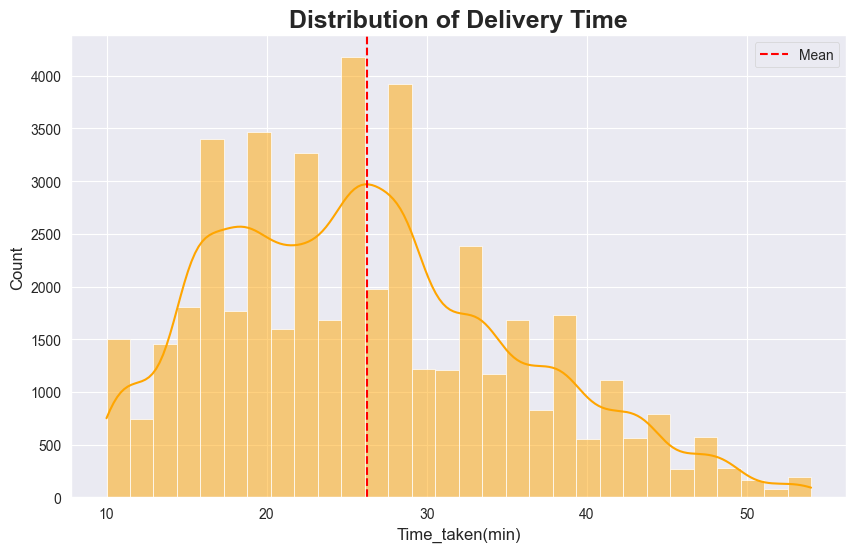

In [331]:
plt.figure(figsize=(10,6))
sns.histplot(data_1['Time_taken(min)'],kde=True,bins=30,color='orange')
plt.axvline(data_1['Time_taken(min)'].mean(),color='red',linestyle='--',label='Mean')
plt.title('Distribution of Delivery Time',fontsize=18,fontweight='bold')
plt.legend()
plt.show()

## Traffic Density vs Delivery Time Boxplot

C:\Users\HP\AppData\Local\Temp\ipykernel_16508\2901987513.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Road_traffic_density',y='Time_taken(min)',data=data_1,palette='Set2')


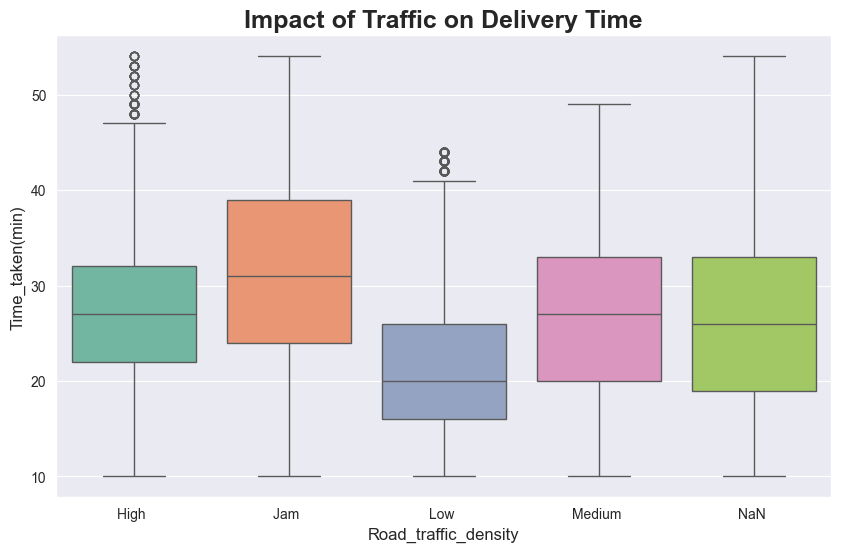

In [332]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Road_traffic_density',y='Time_taken(min)',data=data_1,palette='Set2')
plt.title('Impact of Traffic on Delivery Time',fontsize=18,fontweight='bold')
plt.show()

## Vehicle Type Distribution Piechart

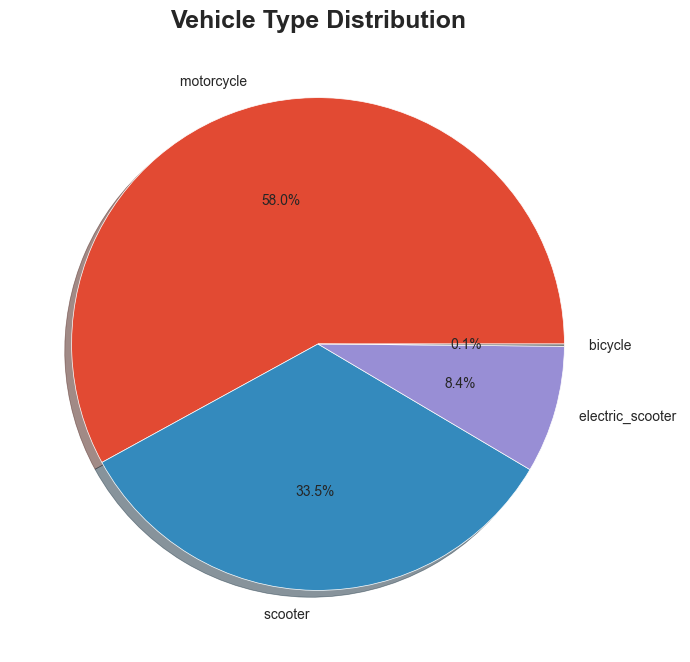

In [333]:
vehicle_counts = data_1['Type_of_vehicle'].value_counts()
plt.figure(figsize=(8,8))
plt.pie(vehicle_counts,labels=vehicle_counts.index,autopct='%1.1f%%',shadow=True)
plt.title('Vehicle Type Distribution',fontsize=18,fontweight='bold')
plt.show()

## Weather Conditions vs Delivery Time Boxplot

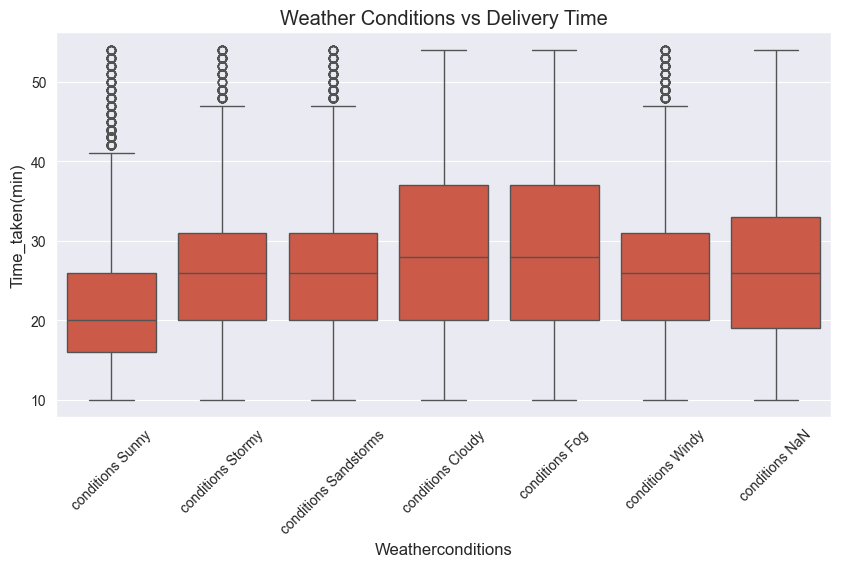

In [323]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Weatherconditions',y='Time_taken(min)',data=data_1)
plt.title('Weather Conditions vs Delivery Time')
plt.xticks(rotation=45)
plt.show()

## Festival Impact Boxplot

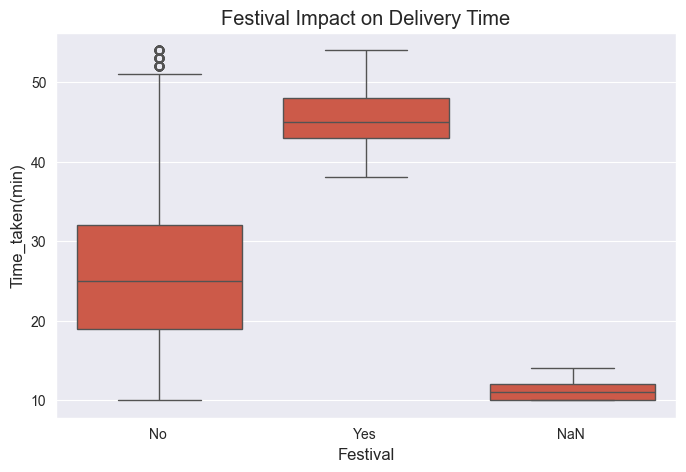

In [325]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Festival',y='Time_taken(min)',data=data_1)
plt.title('Festival Impact on Delivery Time')
plt.show()

## Ratings vs Delivery Time Scatterplot

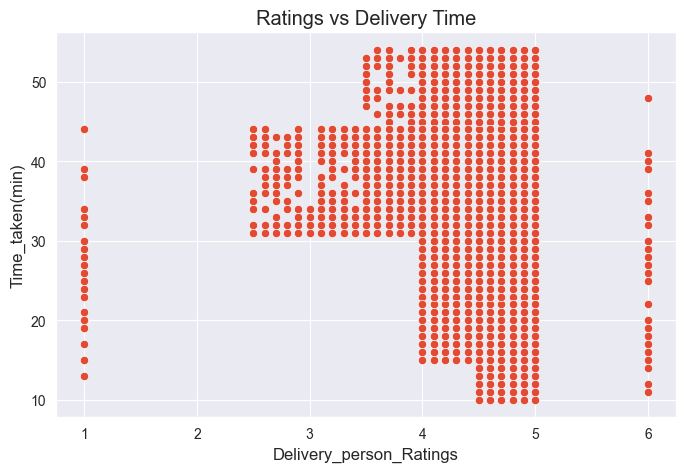

In [326]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Delivery_person_Ratings',y='Time_taken(min)',data=data_1)
plt.title('Ratings vs Delivery Time')
plt.show()

## Correlation Heatmap

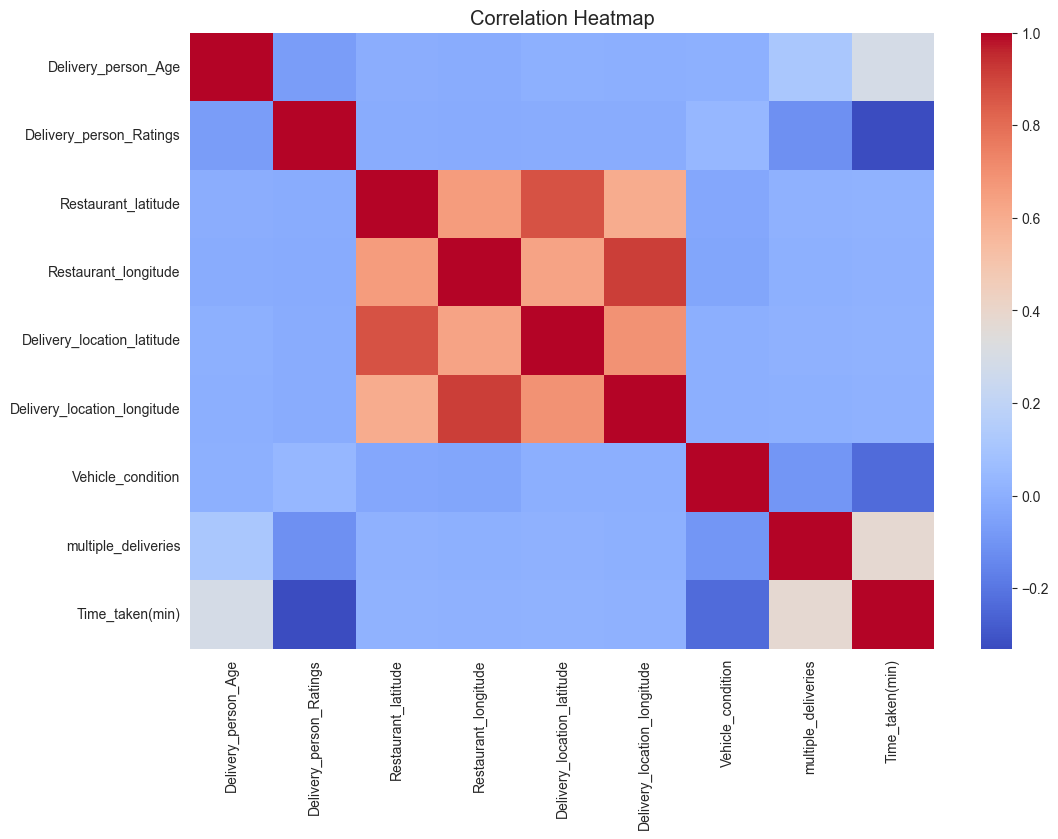

In [327]:
plt.figure(figsize=(12,8))
sns.heatmap(data_1.select_dtypes(include=['int64','float64']).corr(),cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## City Distribution Piechart

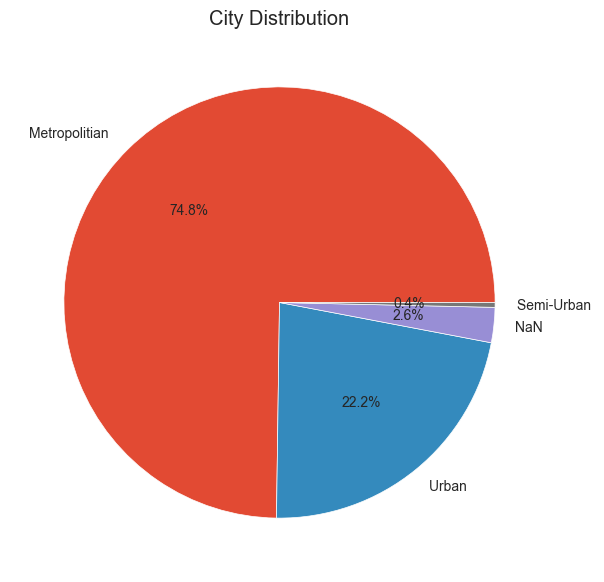

In [328]:
city_counts = data_1['City'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(city_counts,labels=city_counts.index,autopct='%1.1f%%')
plt.title('City Distribution')
plt.show()

# *Separating Features/Columns Of Data_1*

## categorical Columns

In [335]:
categorical_cols = data_1.select_dtypes(include='object').columns

In [336]:
categorical_cols

Index(['Delivery_person_ID', 'Weatherconditions', 'Road_traffic_density',
       'Type_of_order', 'Type_of_vehicle', 'Festival', 'City'],
      dtype='object')

## numerical columns

In [337]:
numerical_cols = data_1.select_dtypes(include=['int64','float64']).columns

In [338]:
numerical_cols

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Vehicle_condition',
       'multiple_deliveries', 'Time_taken(min)'],
      dtype='object')

## Datetime Columns

In [339]:
datetime_cols = data_1.select_dtypes(include='datetime').columns

In [340]:
datetime_cols

Index(['Order_Date', 'Time_Orderd', 'Time_Order_picked'], dtype='object')

## Droping Target Column From Numerical Columns 

In [341]:
numerical_cols = numerical_cols.drop('Time_taken(min)')

In [342]:
numerical_cols

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Vehicle_condition',
       'multiple_deliveries'],
      dtype='object')

# *Datetime feature extraction*

## Data_1

In [343]:
data_1['order_day'] = data_1['Order_Date'].dt.day
data_1['order_month'] = data_1['Order_Date'].dt.month
data_1['order_hour'] = data_1['Time_Orderd'].dt.hour

In [344]:
data_1.head()

,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,...,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),order_day,order_month,order_hour
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,2026-05-23 11:30:00,2026-05-23 11:45:00,...,2,Snack,motorcycle,0.0,No,Urban,24,19,3,11
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,2026-05-23 19:45:00,2026-05-23 19:50:00,...,2,Snack,scooter,1.0,No,Metropolitian,33,25,3,19
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,2026-05-23 08:30:00,2026-05-23 08:45:00,...,0,Drinks,motorcycle,1.0,No,Urban,26,19,3,8
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,2026-05-23 18:00:00,2026-05-23 18:10:00,...,0,Buffet,motorcycle,1.0,No,Metropolitian,21,5,4,18
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,2026-05-23 13:30:00,2026-05-23 13:45:00,...,1,Snack,scooter,1.0,No,Metropolitian,30,26,3,13


## Data_2

In [345]:
data_2['order_day'] = data_2['Order_Date'].dt.day
data_2['order_month'] = data_2['Order_Date'].dt.month
data_2['order_hour'] = data_2['Time_Orderd'].dt.hour

In [346]:
data_2.head()

,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,...,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,order_day,order_month,order_hour
0,COIMBRES13DEL01,30.0,4.7,11.003669,76.976494,11.043669,77.016494,2022-03-30,2026-05-23 18:20:00,2026-05-23 15:05:00,...,NaN,3,Drinks,electric_scooter,1.0,No,Metropolitian,30,3,18
1,BANGRES15DEL01,28.0,4.6,12.975377,77.696664,13.085377,77.806664,2022-03-29,2026-05-23 20:30:00,2026-05-23 20:35:00,...,Jam,0,Snack,motorcycle,1.0,No,Metropolitian,29,3,20
2,JAPRES09DEL03,23.0,4.5,26.911378,75.789034,27.001378,75.879034,2022-03-10,2026-05-23 19:35:00,2026-05-23 19:45:00,...,Jam,0,Drinks,motorcycle,1.0,No,Metropolitian,10,3,19
3,JAPRES07DEL03,21.0,4.8,26.766536,75.837333,26.856536,75.927333,2022-04-02,2026-05-23 17:15:00,2026-05-23 17:20:00,...,Medium,1,Meal,scooter,1.0,No,Metropolitian,2,4,17
4,CHENRES19DEL01,31.0,4.6,12.986047,80.218114,13.096047,80.328114,2022-03-27,2026-05-23 18:25:00,2026-05-23 18:40:00,...,Medium,2,Drinks,scooter,1.0,No,Metropolitian,27,3,18


# *Encode Categorical Columns*

In [347]:
for i in categorical_cols:
    le = LabelEncoder()
    data_1[i] = le.fit_transform(data_1[i])
    data_2[i] = le.transform(data_2[i])

In [348]:
data_1.head()

,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,...,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),order_day,order_month,order_hour
0,637,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,2026-05-23 11:30:00,2026-05-23 11:45:00,...,2,3,2,0.0,1,3,24,19,3,11
1,232,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,2026-05-23 19:45:00,2026-05-23 19:50:00,...,2,3,3,1.0,1,0,33,25,3,19
2,234,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,2026-05-23 08:30:00,2026-05-23 08:45:00,...,0,1,2,1.0,1,3,26,19,3,8
3,397,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,2026-05-23 18:00:00,2026-05-23 18:10:00,...,0,0,2,1.0,1,0,21,5,4,18
4,333,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,2026-05-23 13:30:00,2026-05-23 13:45:00,...,1,3,3,1.0,1,0,30,26,3,13


In [349]:
data_2.head()

,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,...,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,order_day,order_month,order_hour
0,396,30.0,4.7,11.003669,76.976494,11.043669,77.016494,2022-03-30,2026-05-23 18:20:00,2026-05-23 15:05:00,...,4,3,1,1,1.0,1,0,30,3,18
1,222,28.0,4.6,12.975377,77.696664,13.085377,77.806664,2022-03-29,2026-05-23 20:30:00,2026-05-23 20:35:00,...,1,0,3,2,1.0,1,0,29,3,20
2,689,23.0,4.5,26.911378,75.789034,27.001378,75.879034,2022-03-10,2026-05-23 19:35:00,2026-05-23 19:45:00,...,1,0,1,2,1.0,1,0,10,3,19
3,683,21.0,4.8,26.766536,75.837333,26.856536,75.927333,2022-04-02,2026-05-23 17:15:00,2026-05-23 17:20:00,...,3,1,2,3,1.0,1,0,2,4,17
4,354,31.0,4.6,12.986047,80.218114,13.096047,80.328114,2022-03-27,2026-05-23 18:25:00,2026-05-23 18:40:00,...,3,2,1,3,1.0,1,0,27,3,18


# *Droping uncessary columns*

In [350]:
data_1.drop(['Order_Date','Time_Orderd','Time_Order_picked'],axis=1,inplace=True)
data_2.drop(['Order_Date','Time_Orderd','Time_Order_picked'],axis=1,inplace=True)

In [351]:
data_1.head()

,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),order_day,order_month,order_hour
0,637,37.0,4.9,22.745049,75.892471,22.765049,75.912471,5,0,2,3,2,0.0,1,3,24,19,3,11
1,232,34.0,4.5,12.913041,77.683237,13.043041,77.813237,4,1,2,3,3,1.0,1,0,33,25,3,19
2,234,23.0,4.4,12.914264,77.678400,12.924264,77.688400,3,2,0,1,2,1.0,1,3,26,19,3,8
3,397,38.0,4.7,11.003669,76.976494,11.053669,77.026494,5,3,0,0,2,1.0,1,0,21,5,4,18
4,333,32.0,4.6,12.972793,80.249982,13.012793,80.289982,0,0,1,3,3,1.0,1,0,30,26,3,13


In [352]:
data_2.head()

,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,order_day,order_month,order_hour
0,396,30.0,4.7,11.003669,76.976494,11.043669,77.016494,2,4,3,1,1,1.0,1,0,30,3,18
1,222,28.0,4.6,12.975377,77.696664,13.085377,77.806664,6,1,0,3,2,1.0,1,0,29,3,20
2,689,23.0,4.5,26.911378,75.789034,27.001378,75.879034,4,1,0,1,2,1.0,1,0,10,3,19
3,683,21.0,4.8,26.766536,75.837333,26.856536,75.927333,1,3,1,2,3,1.0,1,0,2,4,17
4,354,31.0,4.6,12.986047,80.218114,13.096047,80.328114,5,3,2,1,3,1.0,1,0,27,3,18


# *X / y Separation*

In [353]:
X = data_1.drop('Time_taken(min)', axis=1)
y = data_1['Time_taken(min)']

In [354]:
X.head()

,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,order_day,order_month,order_hour
0,637,37.0,4.9,22.745049,75.892471,22.765049,75.912471,5,0,2,3,2,0.0,1,3,19,3,11
1,232,34.0,4.5,12.913041,77.683237,13.043041,77.813237,4,1,2,3,3,1.0,1,0,25,3,19
2,234,23.0,4.4,12.914264,77.678400,12.924264,77.688400,3,2,0,1,2,1.0,1,3,19,3,8
3,397,38.0,4.7,11.003669,76.976494,11.053669,77.026494,5,3,0,0,2,1.0,1,0,5,4,18
4,333,32.0,4.6,12.972793,80.249982,13.012793,80.289982,0,0,1,3,3,1.0,1,0,26,3,13


In [355]:
y.head()

0    24
1    33
2    26
3    21
4    30
Name: Time_taken(min), dtype: int64

# *Train Test Split*

In [356]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# *Scaling*

In [357]:
scaler = StandardScaler()

In [358]:
X_train = scaler.fit_transform(X_train)

In [359]:
X_train

array([[ 1.42749384,  1.29876284,  0.4971147 , ...,  0.82442691,
         0.03717623, -1.3676216 ],
       [ 0.86671222, -0.28124443, -1.33179004, ..., -1.4747513 ,
         0.03717623,  0.93438642],
       [-0.30269022, -0.98346989, -0.11252021, ..., -1.35979239,
         0.03717623, -0.11198086],
       ...,
       [ 0.59030801,  1.64987557,  0.80193216, ..., -1.4747513 ,
         0.03717623, -0.73980123],
       [-1.18505752, -0.80791352,  0.80193216, ...,  1.39922146,
         0.03717623, -0.11198086],
       [-0.55251711,  0.24542466, -0.11252021, ..., -0.09524437,
         0.03717623,  0.09729259]], shape=(36474, 18))

In [360]:
X_test = scaler.transform(X_test)

In [361]:
X_test

array([[-0.28408609,  0.06986829,  1.10674961, ...,  0.709468  ,
         0.03717623,  0.09729259],
       [ 1.25739894,  0.24542466,  0.19229724, ...,  1.97401601,
         0.03717623,  0.30656605],
       [-0.91131104,  0.94765011, -3.16069477, ...,  1.74409819,
         0.03717623,  0.72511296],
       ...,
       [-1.73520821, -0.63235716,  0.80193216, ...,  0.47955018,
        -1.79521023,  0.72511296],
       [-0.54720164,  0.06986829,  0.19229724, ...,  1.16930364,
         0.03717623,  0.72511296],
       [ 0.91455141,  0.77209375,  0.80193216, ..., -1.4747513 ,
         0.03717623,  0.09729259]], shape=(9119, 18))

In [362]:
data_2 = scaler.transform(data_2)

In [363]:
data_2

array([[-0.9485193 ,  0.06986829,  0.19229724, ...,  1.8590571 ,
         0.03717623,  0.09729259],
       [-1.41096481, -0.28124443, -0.11252021, ...,  1.74409819,
         0.03717623,  0.5158395 ],
       [-0.16980358, -1.15902625, -0.41733767, ..., -0.44012111,
         0.03717623,  0.30656605],
       ...,
       [ 1.27334534,  0.06986829,  0.19229724, ..., -0.32516219,
         0.03717623,  0.09729259],
       [ 1.37433919, -0.4568008 ,  0.19229724, ..., -0.89995675,
         0.03717623,  0.09729259],
       [-1.14519153,  1.64987557,  1.10674961, ...,  1.16930364,
         0.03717623,  0.93438642]], shape=(11399, 18))

# *Bulding Model*

In [364]:
model = Sequential()

## Input and Hidden Layers

In [365]:
model.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))

C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Output Layer

In [366]:
model.add(Dense(1))

# *Compile Model*

In [367]:
model.compile(optimizer='adam',loss='mse',metrics=['mae'])

# *Training Model* 

In [368]:
history = model.fit(X_train,y_train,validation_data=(X_test, y_test),epochs=50,batch_size=32)

Epoch 1/50
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 69.3805 - mae: 6.1556 - val_loss: 40.2017 - val_mae: 5.0706
Epoch 2/50
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 38.4903 - mae: 4.9209 - val_loss: 36.7576 - val_mae: 4.8211
Epoch 3/50
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 35.4596 - mae: 4.7170 - val_loss: 34.9395 - val_mae: 4.7077
Epoch 4/50
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 33.5008 - mae: 4.5754 - val_loss: 33.8784 - val_mae: 4.5838
Epoch 5/50
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 32.3763 - mae: 4.4950 - val_loss: 32.6937 - val_mae: 4.5323
Epoch 6/50
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 31.6398 - mae: 4.4472 - val_loss: 33.4982 - val_mae: 4.6116
Epoch 7/50
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 31.0327 - mae: 4.3952 - val_loss: 31.2279 - val_mae: 4.4022
Epoch 8/50
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 30.3454 - mae: 4.3492 - val_loss: 31.2514 - val_mae: 4.4274
Epoch 9/50
1140/1140 ━━━

# *Evaluate*

In [369]:
loss, mae = model.evaluate(X_test, y_test)
print("MAE:", mae)

285/285 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 26.4934 - mae: 4.0259
MAE: 4.02594518661499


# *Predictions*

In [370]:
predictions = model.predict(data_2)

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


# *Model Summary*

In [371]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           2,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 38,405 (150.02 KB)

 Trainable params: 12,801 (50.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 25,604 (100.02 KB)

In [372]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [373]:
lr_pred = lr.predict(X_test)

In [374]:
print("Linear Regression R2 Score:",r2_score(y_test, lr_pred))

Linear Regression R2 Score: 0.4464256151583501


# *ANN*

In [375]:
y_pred = model.predict(X_test)

285/285 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [379]:
ann = r2_score(y_test, y_pred)
print("ann :", ann)

ann : 0.6978335976600647


# *Random Forest Regressor*

In [380]:
rf = RandomForestRegressor(n_estimators=100,random_state=42)

In [381]:
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [382]:
rf_pred = rf.predict(X_test)

In [383]:
print("Random Forest R2 Score:",r2_score(y_test, rf_pred))

Random Forest R2 Score: 0.7523136309791044


# *XGBoost*

In [384]:
xgb = XGBRegressor(n_estimators=100,learning_rate=0.1,max_depth=6,random_state=42)

In [385]:
xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [386]:
xgb_pred = xgb.predict(X_test)

In [387]:
print("XGBoost R2 Score:",r2_score(y_test, xgb_pred))

XGBoost R2 Score: 0.778488039970398


# *Comparison Table*

In [388]:
print("Linear Regression :", r2_score(y_test, lr_pred))
print("Random Forest :", r2_score(y_test, rf_pred))
print("XGBoost :", r2_score(y_test, xgb_pred))
print("ANN :", ann)

Linear Regression : 0.4464256151583501
Random Forest : 0.7523136309791044
XGBoost : 0.778488039970398
ANN : 0.6978335976600647


# *Predict on Test Dataset*

In [389]:
final_predictions = xgb.predict(data_2)

# *Convert Predictions to DataFrame*

In [390]:
pred_df = pd.DataFrame(final_predictions,columns=['Predicted_Time'])

# *View Predictions*

In [391]:
pred_df.head()

,Predicted_Time
0,23.502890
1,29.496487
2,29.376387
3,28.639198
4,22.129190


# *Model Comparison Barplot*

In [392]:
models = ['Linear Regression','Random Forest','XGBoost','ANN']
scores = [0.446,0.752,0.778,0.693]

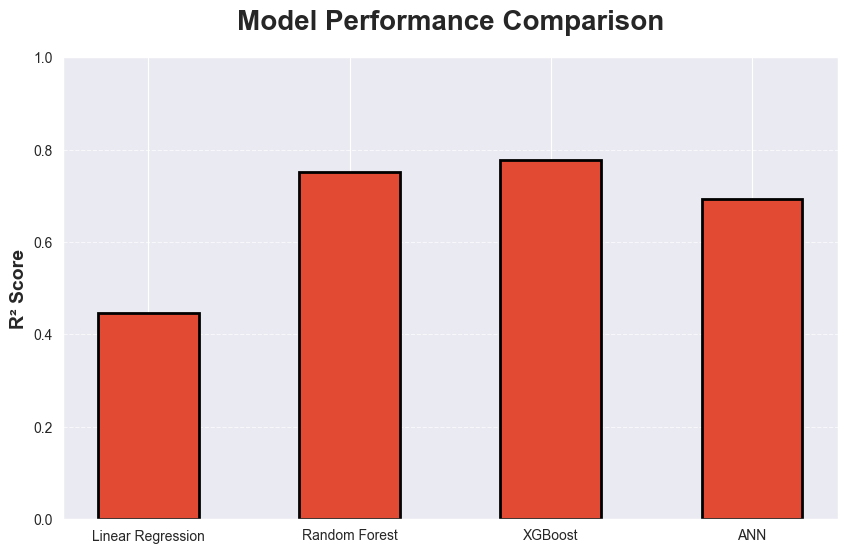

In [395]:
plt.figure(figsize=(10,6))
bars = plt.bar(models,scores,width=0.5,edgecolor='black',linewidth=2)
plt.ylim(0,1)
plt.title('Model Performance Comparison',fontsize=20,fontweight='bold',pad=20)
plt.ylabel('R² Score',fontsize=14,fontweight='bold')
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.show()

# Streamlit